<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_6_NeuralImportanceSampling_Asimov_SameSampleNorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 6 — Neural importance sampling with same-sample normalization

Train a three-member $g_{\boldsymbol{\eta}}$ ensemble with weights
$A_{\mathrm{norm}}$, then select $\epsilon$ using the squared IQR gain $G$.
Reuse the Exercise 5 models. New models and outputs use the `ensemble3` directories.


In [1]:
import os, sys

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_DRIVE = True

import subprocess
from pathlib import Path

DEPENDENCIES = [
    "pytorch-lightning",
    "onnx",
    "onnxruntime",
    "onnxscript",
    "iminuit",
    "mplhep",
    "nflows",
    "pyarrow",
]


def run(*args, env=None):
    """Run one setup command and stop immediately if it fails."""
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"

    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
        run(
            "git", "-C", REPO_DIR, "sparse-checkout", "set",
            "src", "workshops/ml4hep_tifr_colab",
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)

    run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)


    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    run(sys.executable, "-m", "pip", "install", "-q", *DEPENDENCIES)

    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)

    HELPER_DIR = WORK_DIR / "exercise6_same_sample_norm_ensemble3_helpers"
    HELPER_DIR.mkdir(exist_ok=True)
    for module_name in ("utils_nf", "utils_nis"):
        helper_source = subprocess.check_output(
            ["git", "-C", str(REPO_DIR), "show",
             f"FETCH_HEAD:workshops/ml4hep_tifr_colab/{module_name}.py"],
            text=True,
        )
        (HELPER_DIR / f"{module_name}.py").write_text(helper_source)
        sys.modules.pop(module_name, None)
    helper_path = str(HELPER_DIR.resolve())
    if helper_path in sys.path:
        sys.path.remove(helper_path)
    sys.path.insert(0, helper_path)


print("Working dir:", os.getcwd())


Mounted at /content/drive
Working dir: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


## Statistical target

Write $R_s=r_{s,\boldsymbol{\psi}}/\mathbb E_{q_\phi}[r_{s,\boldsymbol{\psi}}]$
for the population-normalized process ratios. This yield-only model has

$$
h_\mu(\mathbf{x})=\mu\lambda_S R_S(\mathbf{x})+\lambda_B R_B(\mathbf{x}),
\qquad h_A=h_{\mu_A},\qquad \mu_A=1.
$$

Define $L_\mu=\log(h_A/h_\mu)$, $Y_\mu=h_A L_\mu$, and
$I_\mu=\mathbb E_{q_\phi}[Y_\mu]$. The expected statistic is
$t_A(\mu)=2[(\mu-\mu_A)\lambda_S+I_\mu]$.

The signal and background normalizers are shared across the yield scan.
Combining their generating-point and tested-point contributions gives

$$
\begin{aligned}
b_S(\mu)&=\lambda_S\mathbb E_{q_\phi}\!\left[
R_S\left\{\mu_A(L_\mu+1)-\mu\frac{h_A}{h_\mu}\right\}\right],\\
b_B(\mu)&=\lambda_B\mathbb E_{q_\phi}\!\left[
R_B\left\{L_\mu+1-\frac{h_A}{h_\mu}\right\}\right],\\
\Psi_\mu(\mathbf{x})&=Y_\mu(\mathbf{x})-I_\mu
-b_S(\mu)[R_S(\mathbf{x})-1]-b_B(\mu)[R_B(\mathbf{x})-1].
\end{aligned}
$$

Thus $\mathbb E_{q_\phi}[\Psi_\mu]=0$. For independent quadrature points from $g$,
with both process ratios normalized on that same weighted sample,

$$
\operatorname{Var}_g[\widehat t_{A,M}(\mu)]
=\frac{4}{M}\int\frac{q_\phi^2(\mathbf{x})}{g(\mathbf{x})}
\Psi_\mu^2(\mathbf{x})\,d\mathbf{x}+o(M^{-1}).
$$

For the same equally weighted scan grid as Exercise 6, use

$$
A_{\mathrm{norm}}(\mathbf{x})=
\left[\frac1K\sum_{k=1}^K
\left(\frac{\Psi_{\mu_k}(\mathbf{x})}{\lambda_A}\right)^2\right]^{1/2},
\qquad
g^*(\mathbf{x})\propto q_\phi(\mathbf{x})A_{\mathrm{norm}}(\mathbf{x}),
$$


where $\lambda_A=\mu_A\lambda_S+\lambda_B$. The pilot fixes the expectations
entering $A_{\mathrm{norm}}$. Train each ensemble member by weighted maximum
likelihood with these amplitudes; $g_{\boldsymbol{\eta}}$ denotes their density
average conditioned on PRESEL.


In [2]:
import gc
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from scipy.special import logsumexp

import torch

from utils_nis import (
    ensemble_log_prob_x, ensemble_sample_x, mixture_log_weights, mix_quadratures,
)

from nsbi_common_utils.training.utils import load_trained_model
from utils import FEATURES, predict_with_model
from utils_plotting import export_standalone_figure_script
from utils_nf import (
    accumulate_preselection_histogram,
    checkpoint_path,
    choose_preselection_ratio_cut,
    load_flow,
    train_flow,
)

FEATURES = list(FEATURES)
N_DIM = len(FEATURES)
SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Features: {FEATURES}")


Using device: cuda
Features: ['x1', 'x2', 'x3', 'x4', 'x5']


## Configuration

Set the ensemble, scan grid, and quadrature sizes.


In [3]:
BASE_PATH = Path("./dataframes")
PRESEL_MODEL_DIR = Path("models_PRESEL")
REFERENCE_FLOW_MODEL_DIR = Path("models_flows_hybrid_reference_spline16_tail5")
RATIO_MODEL_DIR = {
    "signal": Path("models_Hybrid_SigvsRef_5M_ensemble4"),
    "background": Path("models_Hybrid_BkgvsRef_5M_ensemble4"),
}

ORIGINAL_NIS_CACHE_DIR = Path("saved_asimov_nis_influence_v2")
NIS_TRAIN_SEED = SEED + 3201
TUNING_SEED = SEED + 3400
STUDY_SEED = SEED + 300_000
NIS_ENSEMBLE_SIZE = 3

NIS_MODEL_DIR = Path("models_flows_asimov_nis_same_sample_norm_ensemble3")
NIS_PLOT_DIR = Path("plots_asimov_nis_same_sample_norm_ensemble3")
NIS_CACHE_DIR = Path("saved_asimov_nis_same_sample_norm_ensemble3")
FIGURE_SCRIPT_DIR = Path("exercise6_same_sample_norm_ensemble3_figures_scripts")
for directory in [NIS_MODEL_DIR, NIS_PLOT_DIR, NIS_CACHE_DIR, FIGURE_SCRIPT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SAMPLE_PATHS = {
    "signal": BASE_PATH / "signal.parquet",
    "background": BASE_PATH / "background.parquet",
}

SPLIT_SEED = 0
PRESEL_TRAIN_FRACTION = 0.5
FLOW_TRAIN_FRACTION = 0.92
STREAM_BATCH_SIZE = 100_000
PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO = 250.0
PRESEL_CUT_HISTOGRAM_BINS = 4_000
PRESEL_LOG_RATIO_RANGE = (-20.0, 20.0)

RATIO_ENSEMBLE_SIZE = 4
RATIO_EVALUATION_BATCH_SIZE = 100_000
REFERENCE_FLOW_TYPE = "quadratic_spline"
REFERENCE_SAMPLING_BATCH_SIZE = 65_536

ASIMOV_MU_TRUE = 1.0
MU_DESIGN = np.linspace(0.0, 3.0, 13)
MU_SCAN = np.linspace(0.0, 3.0, 61)
PILOT_EVENTS = 2_000_000
DEFENSIVE_FRACTION_CANDIDATES = (0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.0)
N_TUNING_REPETITIONS = 128
ACCEPTANCE_CALIBRATION_EVENTS = 250_000

BENCHMARK_EVENTS = 1_000_000
BENCHMARK_BLOCKS = 10
STUDY_SAMPLE_SIZES = np.asarray(
    [512, 1_024, 2_048, 4_096, 8_192, 16_384, 32_768], dtype=int
)
N_REPETITIONS = 128
SHOWCASE_SAMPLE_SIZE = 2_048

NIS_MODEL_CONFIG = {
    "flow_type": "quadratic_spline",
    "n_features": N_DIM,
    "n_coupling_layers": 12,
    "hidden_features": 1024,
    "hidden_layers": 4,
    "spline_num_bins": 24,
    "spline_tail_bound": 6.0,
    "dropout_probability": 0.0,
}
NIS_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": 70,
    "learning_rate": 1.0e-4,
    "lr_scheduler_factor": 0.2,
    "lr_scheduler_patience": 2,
    "min_learning_rate": 1.0e-7,
    "weight_decay": 0.0,
    "validation_fraction": 0.20,
    "patience": 10,
    "gradient_clip": None,
}


def export_exercise6_figure(fig, script_name):
    """Write a self-contained, editable script for one completed figure."""
    return export_standalone_figure_script(
        fig, script_name=script_name, output_dir=FIGURE_SCRIPT_DIR
    )


## Load PRESEL

Load the Exercise 5 selection and yields.


In [4]:
def as_inference_session(model_candidate):
    if isinstance(model_candidate, ort.InferenceSession):
        return model_candidate
    available = ort.get_available_providers()
    providers = [
        provider
        for provider in ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if provider in available
    ] or available
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    return ort.InferenceSession(
        model_candidate.SerializeToString(),
        sess_options=options,
        providers=providers,
    )


PRESEL_scaler, PRESEL_model_proto = load_trained_model(
    PRESEL_MODEL_DIR / "model0.onnx",
    PRESEL_MODEL_DIR / "model_scaler0.bin",
)
PRESEL_model = as_inference_session(PRESEL_model_proto)
del PRESEL_model_proto


def evaluate_PRESEL_ratio(feature_dataframe):
    ratio = predict_with_model(
        feature_dataframe.astype("float32", copy=False),
        scaler=PRESEL_scaler,
        model=PRESEL_model,
    )
    return np.asarray(ratio, dtype=np.float64).reshape(-1)


PRESEL_STATE_PATH = NIS_CACHE_DIR / "exercise5_preselection_state.npz"
preselection_source = PRESEL_STATE_PATH
for cache_dir in (
    NIS_CACHE_DIR, Path("saved_asimov_nis_same_sample_norm_v2"),
    Path("saved_asimov_nis_same_sample_norm"), ORIGINAL_NIS_CACHE_DIR
):
    candidate = cache_dir / PRESEL_STATE_PATH.name
    if candidate.exists():
        preselection_source = candidate
        break
if preselection_source.exists():
    state = np.load(preselection_source)
    PRESEL_RATIO_CUT = float(state["ratio_cut"])
    LAM_SIG = float(state["lambda_signal"])
    LAM_BKG = float(state["lambda_background"])
    print(f"Loaded cached PRESEL state from {preselection_source}")
else:
    edges = np.linspace(
        PRESEL_LOG_RATIO_RANGE[0],
        PRESEL_LOG_RATIO_RANGE[1],
        PRESEL_CUT_HISTOGRAM_BINS + 1,
    )
    histograms = {}
    statistics = {}
    for sample_name in ["signal", "background"]:
        histograms[sample_name], statistics[sample_name] = (
            accumulate_preselection_histogram(
                SAMPLE_PATHS[sample_name],
                features=FEATURES,
                ratio_predictor=evaluate_PRESEL_ratio,
                log_ratio_edges=edges,
                batch_size=STREAM_BATCH_SIZE,
                presel_fraction=PRESEL_TRAIN_FRACTION,
                flow_train_fraction=FLOW_TRAIN_FRACTION,
                split_seed=SPLIT_SEED,
            )
        )

    PRESEL_RATIO_CUT, diagnostics = choose_preselection_ratio_cut(
        histograms["signal"],
        histograms["background"],
        edges,
        signal_inclusive_yield=statistics["signal"]["inclusive_weight"],
        background_inclusive_yield=statistics["background"]["inclusive_weight"],
        signal_partition_weight=statistics["signal"]["partition_weight"],
        background_partition_weight=statistics["background"]["partition_weight"],
        target_background_to_signal=PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO,
    )
    LAM_SIG = diagnostics["histogram_signal_yield"]
    LAM_BKG = diagnostics["histogram_background_yield"]
    np.savez(
        PRESEL_STATE_PATH,
        ratio_cut=PRESEL_RATIO_CUT,
        lambda_signal=LAM_SIG,
        lambda_background=LAM_BKG,
    )
    print(f"Saved PRESEL state to {PRESEL_STATE_PATH}")

print(f"PRESEL ratio cut: {PRESEL_RATIO_CUT:.6g}")
print(f"Post-selection yields: signal={LAM_SIG:.6g}, background={LAM_BKG:.6g}")
print(f"Post-selection B/S: {LAM_BKG / LAM_SIG:.3f}")


Loaded cached PRESEL state from saved_asimov_nis_influence_v2/exercise5_preselection_state.npz
PRESEL ratio cut: 2.07508
Post-selection yields: signal=611.598, background=152822
Post-selection B/S: 249.874


## Load the hybrid model

Load $q_\phi$ and the Exercise 5 estimates $r_{s,\boldsymbol{\psi}}$.


In [5]:
reference_flow = [load_flow(
    "reference",
    model_dir=REFERENCE_FLOW_MODEL_DIR,
    flow_type=REFERENCE_FLOW_TYPE,
    device=device,
    expected_features=FEATURES,
)]

ratio_models = {}
for sample_name, model_dir in RATIO_MODEL_DIR.items():
    ratio_models[sample_name] = []
    for member in range(RATIO_ENSEMBLE_SIZE):
        scaler, model_proto = load_trained_model(
            model_dir / f"model{member}.onnx",
            model_dir / f"model_scaler{member}.bin",
        )
        ratio_models[sample_name].append(
            {"scaler": scaler, "model": as_inference_session(model_proto)}
        )


def evaluate_ratio(sample_name, values, batch_size=RATIO_EVALUATION_BATCH_SIZE):
    values = np.asarray(values, dtype=np.float32)
    chunks = []
    for start in range(0, len(values), int(batch_size)):
        batch = pd.DataFrame(values[start : start + int(batch_size)], columns=FEATURES)
        member_predictions = []
        for pack in ratio_models[sample_name]:
            prediction = predict_with_model(
                batch,
                scaler=pack["scaler"],
                model=pack["model"],
            )
            member_predictions.append(
                np.asarray(prediction, dtype=np.float64).reshape(-1)
            )
        chunks.append(np.mean(np.stack(member_predictions, axis=0), axis=0))
    return np.concatenate(chunks)



def sample_preselected_flow(flow_pack, n_events, batch_size=65_536):
    accepted_chunks = []
    n_kept = 0
    n_generated = 0
    n_passed = 0
    while n_kept < int(n_events):
        needed = int(n_events) - n_kept
        current_batch = max(int(batch_size), min(4 * int(batch_size), 2 * needed))
        generated = ensemble_sample_x(flow_pack, current_batch, batch_size=batch_size)
        generated_df = pd.DataFrame(generated, columns=FEATURES)
        passes = evaluate_PRESEL_ratio(generated_df) >= PRESEL_RATIO_CUT
        n_generated += len(generated)
        n_passed += int(passes.sum())
        if np.any(passes):
            accepted_chunks.append(generated[passes])
            n_kept += int(passes.sum())
    accepted = np.concatenate(accepted_chunks, axis=0)[: int(n_events)]
    return accepted.astype(np.float32, copy=False), n_passed / n_generated


def conditional_log_prob(flow_pack, values, acceptance, batch_size=65_536):
    return (
        np.asarray(
            ensemble_log_prob_x(flow_pack, values, batch_size=batch_size),
            dtype=np.float64,
        )
        - np.log(float(acceptance))
    )


print(f"Loaded reference flow: {reference_flow[0]['path']}")
print("Loaded four signal/reference and four background/reference models.")


Loaded reference flow: models_flows_hybrid_reference_spline16_tail5/quadratic_spline_reference.pt
Loaded four signal/reference and four background/reference models.


## Build the pilot target

Estimate the expectations in $A_{\mathrm{norm}}$ from the reference sample.


In [6]:
def normalized_ratios(raw_signal, raw_background, weights=None):
    raw_signal = np.asarray(raw_signal, dtype=np.float64)
    raw_background = np.asarray(raw_background, dtype=np.float64)
    if weights is None:
        weights = np.full(len(raw_signal), 1.0 / len(raw_signal))
    else:
        weights = np.asarray(weights, dtype=np.float64)
        weights = weights / weights.sum()
    signal_norm = float(np.sum(weights * raw_signal))
    background_norm = float(np.sum(weights * raw_background))
    return raw_signal / signal_norm, raw_background / background_norm


def fit_scan_normalization_target(raw_signal, raw_background, mu_values):
    """Estimate I_mu and both normalization coefficients on the pilot."""
    raw_signal = np.asarray(raw_signal, dtype=np.float64)
    raw_background = np.asarray(raw_background, dtype=np.float64)
    ratio_normalization = np.asarray([raw_signal.mean(), raw_background.mean()])
    ratio_signal = raw_signal / ratio_normalization[0]
    ratio_background = raw_background / ratio_normalization[1]
    h_asimov = (
        ASIMOV_MU_TRUE * LAM_SIG * ratio_signal + LAM_BKG * ratio_background
    )
    mu_values = np.asarray(mu_values, dtype=np.float64)
    integrals = np.empty(len(mu_values))
    coefficients = np.empty((len(mu_values), 2))
    for k, mu in enumerate(mu_values):
        h_mu = mu * LAM_SIG * ratio_signal + LAM_BKG * ratio_background
        h_ratio = h_asimov / h_mu
        log_h_ratio = np.log(h_ratio)
        integrals[k] = np.mean(h_asimov * log_h_ratio)
        # b_s = b_s^A - b_s^T because the component shapes do not depend on mu.
        coefficients[k, 0] = np.mean(
            ratio_signal * LAM_SIG
            * (ASIMOV_MU_TRUE * (log_h_ratio + 1.0) - mu * h_ratio)
        )
        coefficients[k, 1] = np.mean(
            ratio_background * LAM_BKG * (log_h_ratio + 1.0 - h_ratio)
        )
    return {
        "ratio_normalization": ratio_normalization,
        "mu_values": mu_values,
        "integrals": integrals,
        "coefficients": coefficients,
        "scale": ASIMOV_MU_TRUE * LAM_SIG + LAM_BKG,
    }


def scan_influence_amplitude(raw_signal, raw_background, target):
    """Evaluate A_norm using fixed pilot normalizations and coefficients."""
    ratio_signal = (
        np.asarray(raw_signal, dtype=np.float64) / target["ratio_normalization"][0]
    )
    ratio_background = (
        np.asarray(raw_background, dtype=np.float64) / target["ratio_normalization"][1]
    )
    h_asimov = (
        ASIMOV_MU_TRUE * LAM_SIG * ratio_signal + LAM_BKG * ratio_background
    )
    amplitude_squared = np.zeros(len(ratio_signal), dtype=np.float64)
    for mu, integral, (b_signal, b_background) in zip(
        target["mu_values"], target["integrals"], target["coefficients"]
    ):
        h_mu = mu * LAM_SIG * ratio_signal + LAM_BKG * ratio_background
        y_mu = h_asimov * np.log(h_asimov / h_mu)
        influence_mu = (
            y_mu - integral
            - b_signal * (ratio_signal - 1.0)
            - b_background * (ratio_background - 1.0)
        )
        amplitude_squared += (influence_mu / target["scale"]) ** 2
    return np.sqrt(amplitude_squared / len(target["mu_values"]))


torch.manual_seed(SEED + 100)
pilot_values, REFERENCE_PRESEL_ACCEPTANCE = sample_preselected_flow(
    reference_flow,
    PILOT_EVENTS,
    batch_size=REFERENCE_SAMPLING_BATCH_SIZE,
)
pilot_raw_signal = evaluate_ratio("signal", pilot_values)
pilot_raw_background = evaluate_ratio("background", pilot_values)
RATIO_NORMALIZATION = {
    "signal": float(np.mean(pilot_raw_signal)),
    "background": float(np.mean(pilot_raw_background)),
}

NIS_TARGET_STATE = fit_scan_normalization_target(
    pilot_raw_signal, pilot_raw_background, MU_DESIGN
)
pilot_amplitude = scan_influence_amplitude(
    pilot_raw_signal, pilot_raw_background, NIS_TARGET_STATE
)
np.savez(NIS_CACHE_DIR / "pilot_normalization_target.npz", **NIS_TARGET_STATE)

print(f"Pilot reference events: {len(pilot_values):,}")
print(f"Reference PRESEL acceptance: {REFERENCE_PRESEL_ACCEPTANCE:.4%}")
print("Ratio normalizations:", RATIO_NORMALIZATION)


Pilot reference events: 2,000,000
Reference PRESEL acceptance: 99.5552%
Ratio normalizations: {'signal': 0.9994067737436526, 'background': 0.9997713709814987}


## Train $g_{\boldsymbol{\eta}}$

Train three members with $A_{\mathrm{norm}}$ weights and minibatches of 2048.
Weights are normalized once over the sample, not within minibatches.


In [7]:
importance_training_df = pd.DataFrame(pilot_values, columns=FEATURES)
importance_flow = []
for member in range(NIS_ENSEMBLE_SIZE):
    member_seed = NIS_TRAIN_SEED + member
    torch.manual_seed(member_seed)
    importance_flow.append(train_flow(
        "asimov_importance", importance_training_df, features=FEATURES,
        model_dir=NIS_MODEL_DIR / f"member_{member}",
        model_config=NIS_MODEL_CONFIG, training_config=NIS_TRAINING_CONFIG,
        device=device, sample_weights=pilot_amplitude, max_train_events=None,
        load_if_available=True, seed=member_seed,
    ))

torch.manual_seed(NIS_TRAIN_SEED + 100)
probe, IMPORTANCE_PRESEL_ACCEPTANCE = sample_preselected_flow(
    importance_flow, ACCEPTANCE_CALIBRATION_EVENTS,
    batch_size=REFERENCE_SAMPLING_BATCH_SIZE,
)
print(f"Ensemble PRESEL acceptance: {IMPORTANCE_PRESEL_ACCEPTANCE:.4%}")
del probe, importance_training_df, pilot_values, pilot_raw_signal, pilot_raw_background, pilot_amplitude
gc.collect()


Loading existing asimov_importance flow from models_flows_asimov_nis_same_sample_norm_ensemble3/member_0/quadratic_spline_asimov_importance.pt
Loading existing asimov_importance flow from models_flows_asimov_nis_same_sample_norm_ensemble3/member_1/quadratic_spline_asimov_importance.pt
Loading existing asimov_importance flow from models_flows_asimov_nis_same_sample_norm_ensemble3/member_2/quadratic_spline_asimov_importance.pt
Ensemble PRESEL acceptance: 99.6387%


153

## Compare $g_{\boldsymbol{\eta}}$ with $A_{\mathrm{norm}}$

Plot centered $\log[g_{\boldsymbol{\eta}}/q_\phi]$ against centered
$\log A_{\mathrm{norm}}$ on reference events.


Wrote standalone figure script: exercise6_same_sample_norm_ensemble3_figures_scripts/proposal_target_closure.py


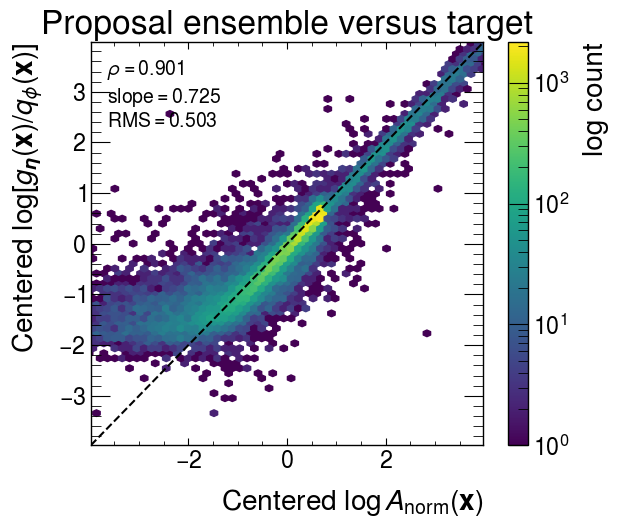

Proposal/target correlation: 0.900964
Proposal/target slope: 0.724539
Centered log-ratio RMS: 0.502547


In [8]:
VALIDATION_EVENTS = 200_000
torch.manual_seed(STUDY_SEED + 400)
validation_values, _ = sample_preselected_flow(
    reference_flow, VALIDATION_EVENTS, batch_size=REFERENCE_SAMPLING_BATCH_SIZE
)
validation_raw_signal = evaluate_ratio("signal", validation_values)
validation_raw_background = evaluate_ratio("background", validation_values)
validation_amplitude = scan_influence_amplitude(
    validation_raw_signal, validation_raw_background, NIS_TARGET_STATE
)
validation_log_q = conditional_log_prob(
    reference_flow, validation_values, REFERENCE_PRESEL_ACCEPTANCE
)
validation_log_g = conditional_log_prob(
    importance_flow, validation_values, IMPORTANCE_PRESEL_ACCEPTANCE
)
log_target = np.log(validation_amplitude)
log_proposal_ratio = validation_log_g - validation_log_q
log_target_centered = log_target - np.mean(log_target)
log_proposal_centered = log_proposal_ratio - np.mean(log_proposal_ratio)
proposal_target_correlation = float(
    np.corrcoef(log_target_centered, log_proposal_centered)[0, 1]
)
proposal_target_slope = float(
    np.polyfit(log_target_centered, log_proposal_centered, deg=1)[0]
)
proposal_target_rmse = float(
    np.sqrt(np.mean((log_proposal_centered - log_target_centered) ** 2))
)

rng = np.random.default_rng(STUDY_SEED + 401)
plot_indices = rng.choice(
    len(validation_values), size=min(40_000, len(validation_values)), replace=False
)
limit = np.quantile(
    np.abs(
        np.concatenate(
            [log_target_centered[plot_indices], log_proposal_centered[plot_indices]]
        )
    ),
    0.995,
)

fig, ax = plt.subplots(figsize=(6.4, 5.5))
hexbin = ax.hexbin(
    log_target_centered[plot_indices],
    log_proposal_centered[plot_indices],
    gridsize=70,
    bins="log",
    mincnt=1,
    cmap="viridis",
)
ax.plot([-limit, limit], [-limit, limit], color="black", ls="--", lw=1.5)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_xlabel(r"Centered $\log A_{\mathrm{norm}}(\mathbf{x})$")
ax.set_ylabel(r"Centered $\log[g_{\boldsymbol{\eta}}(\mathbf{x})/q_\phi(\mathbf{x})]$")
ax.set_title("Proposal ensemble versus target")
ax.text(
    0.04,
    0.96,
    rf"$\rho={proposal_target_correlation:.3f}$"
    + "\n"
    + rf"slope$={proposal_target_slope:.3f}$"
    + "\n"
    + rf"RMS$={proposal_target_rmse:.3f}$",
    transform=ax.transAxes,
    va="top",
)
fig.colorbar(hexbin, ax=ax, label="log count")
fig.tight_layout()
fig.savefig(NIS_PLOT_DIR / "proposal_target_closure.png", dpi=160)
export_exercise6_figure(fig, "proposal_target_closure")
plt.show()

print(f"Proposal/target correlation: {proposal_target_correlation:.6f}")
print(f"Proposal/target slope: {proposal_target_slope:.6f}")
print(f"Centered log-ratio RMS: {proposal_target_rmse:.6f}")


## Asimov scans

Construct the same-sample normalized scan and its numerical benchmark.


Constructing a high-statistics numerical benchmark...
Benchmark q_0,A: 3.22719507 +/- 0.00257520 (blocks)
Benchmark sigma_mu: 0.55665664
Benchmark score at mu_A: +2.988e-12
Wrote standalone figure script: exercise6_same_sample_norm_ensemble3_figures_scripts/asimov_benchmark_scan.py


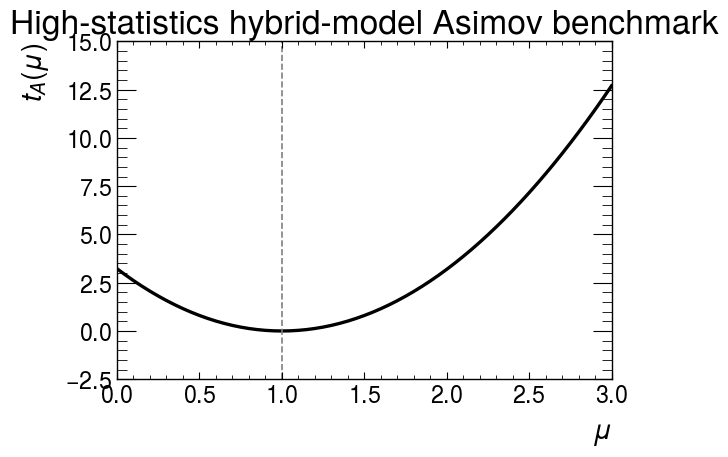

In [9]:
def normalized_importance_weights(log_weights):
    return np.exp(log_weights - logsumexp(log_weights))


def asimov_scan(raw_signal, raw_background, mu_values, log_weights=None):
    raw_signal = np.asarray(raw_signal, dtype=np.float64)
    raw_background = np.asarray(raw_background, dtype=np.float64)
    if log_weights is None:
        weights = np.full(len(raw_signal), 1.0 / len(raw_signal))
    else:
        weights = normalized_importance_weights(log_weights)

    ratio_signal, ratio_background = normalized_ratios(
        raw_signal, raw_background, weights
    )
    h_asimov = (
        ASIMOV_MU_TRUE * LAM_SIG * ratio_signal
        + LAM_BKG * ratio_background
    )

    scan = []
    for mu in np.asarray(mu_values, dtype=np.float64):
        h_mu = mu * LAM_SIG * ratio_signal + LAM_BKG * ratio_background
        integral = np.sum(weights * h_asimov * np.log(h_asimov / h_mu))
        statistic = 2.0 * (
            (mu - ASIMOV_MU_TRUE) * LAM_SIG + integral
        )
        scan.append(float(statistic))

    score_at_truth = 2.0 * LAM_SIG * (
        1.0 - float(np.sum(weights * ratio_signal))
    )
    ess = 1.0 / np.sum(weights**2)
    return np.asarray(scan), float(score_at_truth), float(ess)


def evaluate_hybrid_ratios(values):
    return evaluate_ratio("signal", values), evaluate_ratio("background", values)


print("Constructing a high-statistics numerical benchmark...")
torch.manual_seed(SEED + 600)
benchmark_values, _ = sample_preselected_flow(
    reference_flow, BENCHMARK_EVENTS, batch_size=REFERENCE_SAMPLING_BATCH_SIZE
)
benchmark_raw_signal, benchmark_raw_background = evaluate_hybrid_ratios(
    benchmark_values
)
del benchmark_values
gc.collect()
BENCHMARK_SCAN, BENCHMARK_SCORE, BENCHMARK_ESS = asimov_scan(
    benchmark_raw_signal, benchmark_raw_background, MU_SCAN
)
zero_index = int(np.argmin(np.abs(MU_SCAN)))
BENCHMARK_Q_ZERO = float(BENCHMARK_SCAN[zero_index])
BENCHMARK_SIGMA = ASIMOV_MU_TRUE / np.sqrt(BENCHMARK_Q_ZERO)

# A block estimate makes clear that this is a precise numerical benchmark, not
# an analytic truth curve.
benchmark_block_q0 = []
for block in np.array_split(np.arange(BENCHMARK_EVENTS), BENCHMARK_BLOCKS):
    block_scan, _, _ = asimov_scan(
        benchmark_raw_signal[block], benchmark_raw_background[block], MU_SCAN
    )
    benchmark_block_q0.append(block_scan[zero_index])
BENCHMARK_Q_ZERO_SE = float(
    np.std(benchmark_block_q0, ddof=1) / np.sqrt(BENCHMARK_BLOCKS)
)

print(f"Benchmark q_0,A: {BENCHMARK_Q_ZERO:.8f} +/- {BENCHMARK_Q_ZERO_SE:.8f} (blocks)")
print(f"Benchmark sigma_mu: {BENCHMARK_SIGMA:.8f}")
print(f"Benchmark score at mu_A: {BENCHMARK_SCORE:+.3e}")

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(MU_SCAN, BENCHMARK_SCAN, color="black", lw=2.4)
ax.axvline(ASIMOV_MU_TRUE, color="0.5", ls="--", lw=1.2)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$t_A(\mu)$")
ax.set_title("High-statistics hybrid-model Asimov benchmark")
fig.tight_layout()
fig.savefig(NIS_PLOT_DIR / "asimov_benchmark_scan.png", dpi=160)
export_exercise6_figure(fig, "asimov_benchmark_scan")
plt.show()


## Select $\epsilon$ using $G$

With the trained ensemble fixed, evaluate
$g_\epsilon=(1-\epsilon)g_{\boldsymbol{\eta}}+\epsilon q_\phi$ and select the largest
$$
G(\epsilon)=\left[
\frac{\operatorname{IQR}(q_{0,A}^{\mathrm{direct}})}
{\operatorname{IQR}(q_{0,A}^{g_\epsilon})}
\right]^2
$$
from repeated quadratures at $M=2048$. Each $\epsilon$ uses the same event pools.


Epsilon selection: 16/128
Epsilon selection: 32/128
Epsilon selection: 48/128
Epsilon selection: 64/128
Epsilon selection: 80/128
Epsilon selection: 96/128
Epsilon selection: 112/128
Epsilon selection: 128/128


,epsilon,q0_iqr,G
0,0.00,0.029633,5.258276
1,0.01,0.032189,4.456272
2,0.02,0.031186,4.747573
3,0.05,0.026393,6.628402
4,0.10,0.025842,6.914042
5,0.20,0.026018,6.821080
6,0.30,0.026794,6.431314
7,0.50,0.024539,7.667643
8,1.00,0.067951,1.000000


Selected epsilon=0.1
Wrote standalone figure script: exercise6_same_sample_norm_ensemble3_figures_scripts/epsilon_iqr_gain.py


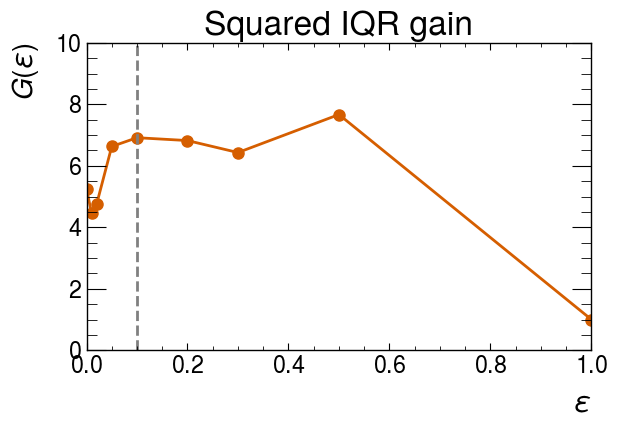

In [13]:
def quadrature_pool(values):
    raw_signal, raw_background = evaluate_hybrid_ratios(values)
    log_q = conditional_log_prob(reference_flow, values, REFERENCE_PRESEL_ACCEPTANCE)
    log_g = conditional_log_prob(importance_flow, values, IMPORTANCE_PRESEL_ACCEPTANCE)
    return {"signal": raw_signal, "background": raw_background,
            "log_g_over_q": log_g - log_q}


def draw_quadrature_pools(sample_size, seed):
    torch.manual_seed(seed)
    q_values, _ = sample_preselected_flow(
        reference_flow, sample_size, batch_size=REFERENCE_SAMPLING_BATCH_SIZE
    )
    torch.manual_seed(seed + 10_000)
    g_values, _ = sample_preselected_flow(
        importance_flow, sample_size, batch_size=REFERENCE_SAMPLING_BATCH_SIZE
    )
    uniforms = np.random.default_rng(seed + 20_000).random(sample_size)
    return quadrature_pool(q_values), quadrature_pool(g_values), uniforms


epsilon_rows = []
for repetition in range(N_TUNING_REPETITIONS):
    q_pool, g_pool, uniforms = draw_quadrature_pools(
        SHOWCASE_SAMPLE_SIZE, TUNING_SEED + repetition
    )
    for epsilon in DEFENSIVE_FRACTION_CANDIDATES:
        raw_s, raw_b, log_w = mix_quadratures(q_pool, g_pool, uniforms, epsilon)
        scan, _, _ = asimov_scan(raw_s, raw_b, [0.0], log_weights=log_w)
        epsilon_rows.append({"epsilon": epsilon, "repetition": repetition,
                             "q_zero": float(scan[0])})
    if (repetition + 1) % 16 == 0:
        print(f"Epsilon selection: {repetition + 1}/{N_TUNING_REPETITIONS}", flush=True)

epsilon_results = pd.DataFrame(epsilon_rows)
epsilon_summary = epsilon_results.groupby("epsilon")["q_zero"].agg(
    q0_iqr=lambda values: np.quantile(values, 0.75) - np.quantile(values, 0.25)
).reset_index()
direct_iqr = float(epsilon_summary.loc[epsilon_summary["epsilon"] == 1.0, "q0_iqr"].iloc[0])
epsilon_summary["G"] = (direct_iqr / epsilon_summary["q0_iqr"]) ** 2
DEFENSIVE_REFERENCE_FRACTION = float(
    epsilon_summary.loc[epsilon_summary["G"].idxmax(), "epsilon"]
)
DEFENSIVE_REFERENCE_FRACTION = 0.1
epsilon_results.to_csv(NIS_CACHE_DIR / "epsilon_tuning_results.csv", index=False)
epsilon_summary.to_csv(NIS_CACHE_DIR / "epsilon_tuning_summary.csv", index=False)
display(epsilon_summary)
print(f"Selected epsilon={DEFENSIVE_REFERENCE_FRACTION:g}")

fig, ax = plt.subplots(figsize=(6.4, 4.5))
ax.plot(epsilon_summary["epsilon"], epsilon_summary["G"], "o-")
ax.axvline(DEFENSIVE_REFERENCE_FRACTION, color="0.5", ls="--")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$G(\epsilon)$")
ax.set_title("Squared IQR gain")
fig.tight_layout()
fig.savefig(NIS_PLOT_DIR / "epsilon_iqr_gain.png", dpi=160)
export_exercise6_figure(fig, "epsilon_iqr_gain")
plt.show()


## Importance-weighted closure

Reweight $g_\epsilon$ events to $q_\phi$ using the selected $\epsilon$.


NameError: name 'validation_values' is not defined

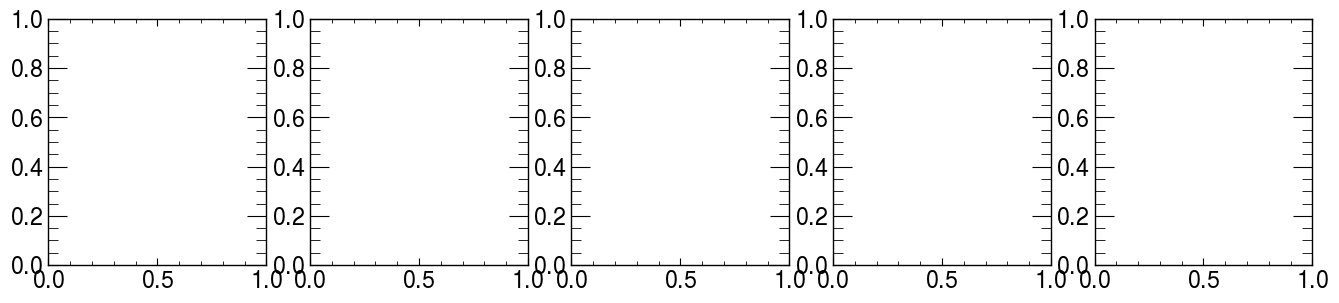

In [15]:
def log_defensive_proposal(values):
    log_q = conditional_log_prob(
        reference_flow, values, REFERENCE_PRESEL_ACCEPTANCE
    )
    log_g = conditional_log_prob(
        importance_flow, values, IMPORTANCE_PRESEL_ACCEPTANCE
    )
    log_mix = log_q - mixture_log_weights(log_g - log_q, DEFENSIVE_REFERENCE_FRACTION)
    return log_mix, log_q


def sample_defensive_proposal(n_events, seed):
    rng = np.random.default_rng(seed)
    n_reference = int(rng.binomial(int(n_events), DEFENSIVE_REFERENCE_FRACTION))
    n_importance = int(n_events) - n_reference

    torch.manual_seed(seed + 1)
    reference_values, _ = sample_preselected_flow(
        reference_flow, n_reference, batch_size=REFERENCE_SAMPLING_BATCH_SIZE
    ) if n_reference else (np.empty((0, N_DIM), dtype=np.float32), np.nan)
    torch.manual_seed(seed + 2)
    importance_values, _ = sample_preselected_flow(
        importance_flow, n_importance, batch_size=REFERENCE_SAMPLING_BATCH_SIZE
    ) if n_importance else (np.empty((0, N_DIM), dtype=np.float32), np.nan)

    values = np.concatenate([reference_values, importance_values], axis=0)
    values = values[rng.permutation(len(values))]
    log_mix, log_q = log_defensive_proposal(values)
    return values, log_q - log_mix


torch.manual_seed(STUDY_SEED + 500)
proposal_validation_values, proposal_validation_log_weights = (
    sample_defensive_proposal(VALIDATION_EVENTS, STUDY_SEED + 500)
)
proposal_validation_weights = normalized_importance_weights(
    proposal_validation_log_weights
)
proposal_validation_ess = 1.0 / np.sum(proposal_validation_weights**2)

fig, axes = plt.subplots(1, N_DIM, figsize=(3.2 * N_DIM, 3.2))
for axis, feature_index, feature_name in zip(axes, range(N_DIM), FEATURES):
    combined = np.concatenate(
        [validation_values[:, feature_index], proposal_validation_values[:, feature_index]]
    )
    edges = np.quantile(combined, np.linspace(0.001, 0.999, 41))
    edges = np.unique(edges)
    axis.hist(
        validation_values[:, feature_index],
        bins=edges,
        density=True,
        histtype="step",
        lw=2,
        label=r"Direct $q_\phi$",
    )
    axis.hist(
        proposal_validation_values[:, feature_index],
        bins=edges,
        weights=proposal_validation_weights,
        density=True,
        histtype="step",
        lw=1.8,
        label=r"$g_\epsilon$, weighted",
    )
    axis.set_xlabel(feature_name)
    axis.set_ylabel("Density")
axes[0].legend(fontsize=8)
fig.suptitle("Importance-reweighted reference closure", y=1.02)
fig.tight_layout()
fig.savefig(NIS_PLOT_DIR / "importance_reweighted_reference_closure.png", dpi=160)
export_exercise6_figure(fig, "importance_reweighted_reference_closure")
plt.show()

del (
    validation_values, validation_raw_signal, validation_raw_background,
    validation_amplitude, validation_log_q, validation_log_g,
    proposal_validation_values, proposal_validation_log_weights,
    proposal_validation_weights,
)
gc.collect()


## Repeated quadratures

Compare the fixed $g_\epsilon$ with $q_\phi$ on fresh repetitions.


In [16]:
maximum_study_size = int(np.max(STUDY_SAMPLE_SIZES))
rows = []
showcase_scans = {"Direct reference": [], "Neural importance": []}
for repetition in range(N_REPETITIONS):
    q_pool, g_pool, uniforms = draw_quadrature_pools(
        maximum_study_size, STUDY_SEED + 10_000 + repetition
    )
    direct_raw_signal, direct_raw_background = q_pool["signal"], q_pool["background"]
    importance_raw_signal, importance_raw_background, importance_log_weights = mix_quadratures(
        q_pool, g_pool, uniforms, DEFENSIVE_REFERENCE_FRACTION
    )
    for sample_size in STUDY_SAMPLE_SIZES:
        sample_size = int(sample_size)
        for method, raw_s, raw_b, log_w in [
            ("Direct reference", direct_raw_signal, direct_raw_background, None),
            ("Neural importance", importance_raw_signal, importance_raw_background, importance_log_weights),
        ]:
            scan, score, ess = asimov_scan(
                raw_s[:sample_size], raw_b[:sample_size], MU_SCAN,
                log_weights=None if log_w is None else log_w[:sample_size],
            )
            rows.append({
                "method": method, "repetition": repetition, "sample_size": sample_size,
                "q_zero": float(scan[zero_index]),
                "q_zero_error": float(scan[zero_index] - BENCHMARK_Q_ZERO),
                "scan_rmse": float(np.sqrt(np.mean((scan - BENCHMARK_SCAN)**2))),
                "score_at_truth": score, "ess": ess,
            })
            if sample_size == SHOWCASE_SAMPLE_SIZE and repetition < 8:
                showcase_scans[method].append(scan)
    if (repetition + 1) % 16 == 0:
        print(f"Comparison: {repetition + 1}/{N_REPETITIONS}", flush=True)

study_results = pd.DataFrame(rows)
study_summary = study_results.groupby(["method", "sample_size"], sort=False).agg(
    q0_mean=("q_zero", "mean"),
    q0_std=("q_zero", "std"),
    q0_iqr=("q_zero", lambda values: np.quantile(values, 0.75) - np.quantile(values, 0.25)),
    q0_rmse=("q_zero_error", lambda values: np.sqrt(np.mean(values**2))),
    scan_rmse=("scan_rmse", lambda values: np.sqrt(np.mean(values**2))),
).reset_index()
direct_iqr = study_summary[study_summary["method"] == "Direct reference"].set_index("sample_size")["q0_iqr"]
study_summary["G"] = (study_summary["sample_size"].map(direct_iqr) / study_summary["q0_iqr"]) ** 2
study_results.to_csv(NIS_CACHE_DIR / "study_results.csv", index=False)
study_summary.to_csv(NIS_CACHE_DIR / "study_summary.csv", index=False)
display(study_summary)
np.savez(
    NIS_CACHE_DIR / "benchmark_and_scans.npz", mu_scan=MU_SCAN,
    benchmark_scan=BENCHMARK_SCAN, benchmark_q0=BENCHMARK_Q_ZERO,
    benchmark_q0_se=BENCHMARK_Q_ZERO_SE, benchmark_block_q0=benchmark_block_q0,
    showcase_direct=showcase_scans["Direct reference"],
    showcase_nis=showcase_scans["Neural importance"],
)

import json
settings = {
    "target": "same_sample_normalization", "training_weights": "A_norm",
    "ensemble_size": NIS_ENSEMBLE_SIZE, "training_seed": NIS_TRAIN_SEED,
    "tuning_seed": TUNING_SEED, "study_seed": STUDY_SEED,
    "epsilon_objective": "squared_iqr_ratio", "epsilon_candidates": list(DEFENSIVE_FRACTION_CANDIDATES),
    "defensive_reference_fraction": DEFENSIVE_REFERENCE_FRACTION,
    "tuning_repetitions": N_TUNING_REPETITIONS, "repetitions": N_REPETITIONS,
    "showcase_sample_size": SHOWCASE_SAMPLE_SIZE, "study_sample_sizes": STUDY_SAMPLE_SIZES.tolist(),
    "pilot_events": PILOT_EVENTS, "benchmark_events": BENCHMARK_EVENTS,
    "mu_true": ASIMOV_MU_TRUE, "mu_design": MU_DESIGN.tolist(), "mu_scan": MU_SCAN.tolist(),
    "lambda_signal": LAM_SIG, "lambda_background": LAM_BKG,
    "reference_preselection_acceptance": REFERENCE_PRESEL_ACCEPTANCE,
    "importance_preselection_acceptance": IMPORTANCE_PRESEL_ACCEPTANCE,
    "reference_checkpoint": str(reference_flow[0]["path"]),
    "importance_checkpoints": [str(member["path"]) for member in importance_flow],
    "model_config": NIS_MODEL_CONFIG, "training_config": NIS_TRAINING_CONFIG,
}
(NIS_CACHE_DIR / "comparison_settings.json").write_text(json.dumps(settings, indent=2) + "\n")


Comparison: 16/128
Comparison: 32/128
Comparison: 48/128
Comparison: 64/128
Comparison: 80/128
Comparison: 96/128
Comparison: 112/128
Comparison: 128/128


,method,sample_size,q0_mean,q0_std,q0_iqr,q0_rmse,scan_rmse,G
0,Direct reference,512,3.247758,0.113375,0.158621,0.114788,0.164317,1.000000
1,Neural importance,512,3.231026,0.041346,0.057032,0.041362,0.059983,7.735449
2,Direct reference,1024,3.232710,0.072625,0.089115,0.072551,0.103778,1.000000
3,Neural importance,1024,3.231525,0.030673,0.038230,0.030859,0.044871,5.433748
4,Direct reference,2048,3.229623,0.053430,0.069808,0.053276,0.076313,1.000000
5,Neural importance,2048,3.231924,0.021391,0.029986,0.021826,0.031678,5.419703
6,Direct reference,4096,3.226794,0.038288,0.049168,0.038141,0.054682,1.000000
7,Neural importance,4096,3.230857,0.013222,0.015217,0.013670,0.019923,10.440513
8,Direct reference,8192,3.228322,0.027282,0.033568,0.027199,0.039037,1.000000
9,Neural importance,8192,3.229953,0.009277,0.011156,0.009643,0.014033,9.054037


2898

Wrote standalone figure script: exercise6_same_sample_norm_ensemble3_figures_scripts/nis_asimov_convergence.py


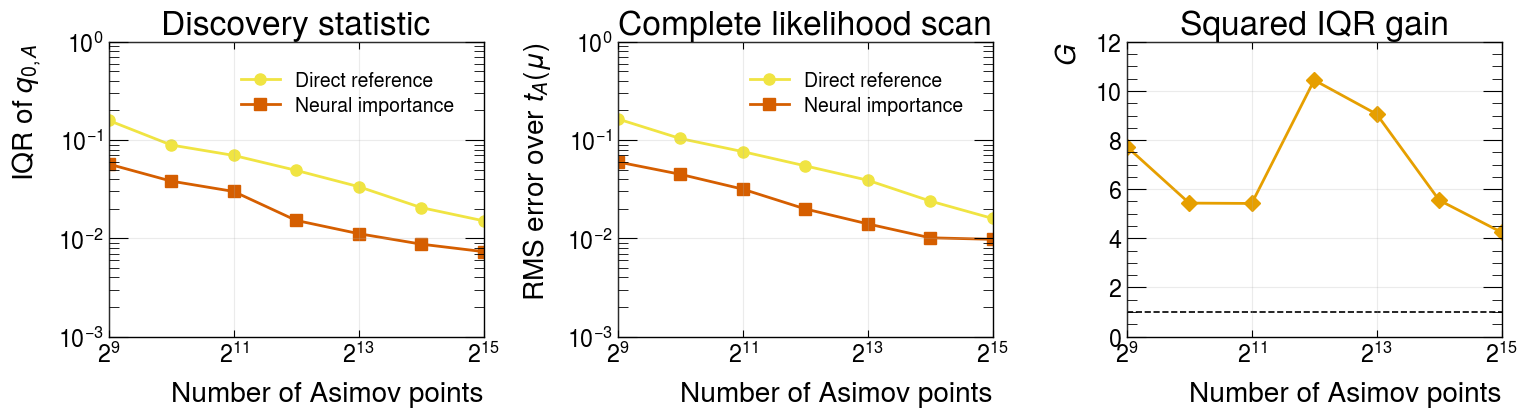

In [17]:
colors = {"Direct reference": "C3", "Neural importance": "C0"}
markers = {"Direct reference": "o", "Neural importance": "s"}

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
for method, group in study_summary.groupby("method", sort=False):
    group = group.sort_values("sample_size")
    axes[0].plot(
        group["sample_size"],
        group["q0_iqr"],
        marker=markers[method],
        color=colors[method],
        lw=2,
        label=method,
    )
    axes[1].plot(
        group["sample_size"],
        group["scan_rmse"],
        marker=markers[method],
        color=colors[method],
        lw=2,
        label=method,
    )

nis_summary = study_summary[
    study_summary["method"] == "Neural importance"
].sort_values("sample_size")
axes[2].plot(
    nis_summary["sample_size"],
    nis_summary["G"],
    marker="D",
    color="C2",
    lw=2,
)
axes[2].axhline(1.0, color="black", ls="--", lw=1.2)

for axis in axes[:2]:
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.grid(alpha=0.25)
    axis.legend()
axes[2].set_xscale("log", base=2)
axes[2].grid(alpha=0.25)
axes[0].set_xlabel("Number of Asimov points")
axes[0].set_ylabel(r"IQR of $q_{0,A}$")
axes[0].set_title("Discovery statistic")
axes[1].set_xlabel("Number of Asimov points")
axes[1].set_ylabel(r"RMS error over $t_A(\mu)$")
axes[1].set_title("Complete likelihood scan")
axes[2].set_xlabel("Number of Asimov points")
axes[2].set_ylabel(r"$G$")
axes[2].set_title("Squared IQR gain")
fig.tight_layout()
fig.savefig(NIS_PLOT_DIR / "nis_asimov_convergence.png", dpi=160)
export_exercise6_figure(fig, "nis_asimov_convergence")
plt.show()


Wrote standalone figure script: exercise6_same_sample_norm_ensemble3_figures_scripts/nis_repeated_small_asimov_scans.py


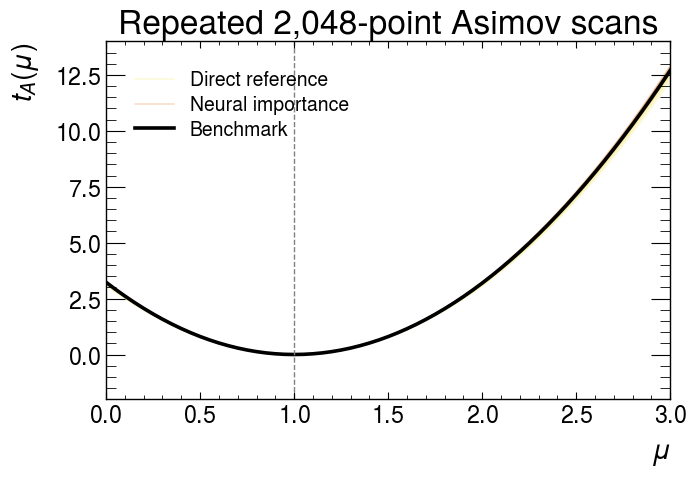

In [18]:
fig, ax = plt.subplots(figsize=(7.0, 5.0))
for method in ["Direct reference", "Neural importance"]:
    for index, scan in enumerate(showcase_scans[method]):
        ax.plot(
            MU_SCAN,
            scan,
            color=colors[method],
            alpha=0.20,
            lw=1.2,
            label=method if index == 0 else None,
        )
ax.plot(MU_SCAN, BENCHMARK_SCAN, color="black", lw=2.6, label="Benchmark")
ax.axvline(ASIMOV_MU_TRUE, color="0.5", ls="--", lw=1.0)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$t_A(\mu)$")
ax.set_title(f"Repeated {SHOWCASE_SAMPLE_SIZE:,}-point Asimov scans")
ax.legend()
fig.tight_layout()
fig.savefig(NIS_PLOT_DIR / "nis_repeated_small_asimov_scans.png", dpi=160)
export_exercise6_figure(fig, "nis_repeated_small_asimov_scans")
plt.show()


Wrote standalone figure script: exercise6_same_sample_norm_ensemble3_figures_scripts/nis_q0_equal_cost.py


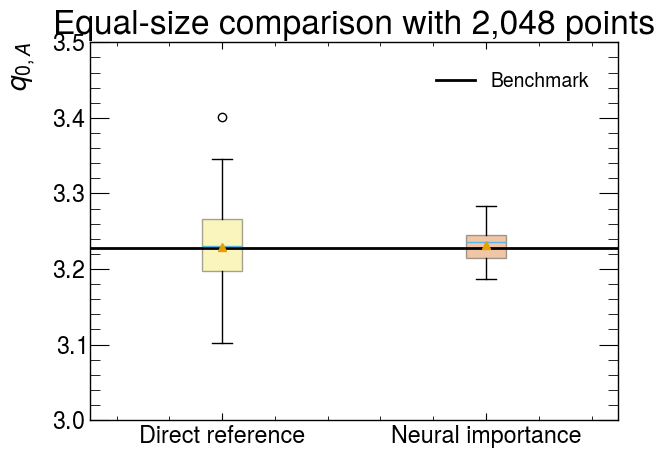

In [19]:
selected_results = study_results[
    study_results["sample_size"] == SHOWCASE_SAMPLE_SIZE
]
fig, ax = plt.subplots(figsize=(6.5, 4.8))
data = [
    selected_results.loc[selected_results["method"] == method, "q_zero"].to_numpy()
    for method in ["Direct reference", "Neural importance"]
]
box = ax.boxplot(
    data,
    tick_labels=["Direct reference", "Neural importance"],
    patch_artist=True,
    showmeans=True,
)
for patch, color in zip(box["boxes"], [colors["Direct reference"], colors["Neural importance"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)
ax.axhline(BENCHMARK_Q_ZERO, color="black", lw=2, label="Benchmark")
ax.set_ylabel(r"$q_{0,A}$")
ax.set_title(f"Equal-size comparison with {SHOWCASE_SAMPLE_SIZE:,} points")
ax.legend()
fig.tight_layout()
fig.savefig(NIS_PLOT_DIR / "nis_q0_equal_cost.png", dpi=160)
export_exercise6_figure(fig, "nis_q0_equal_cost")
plt.show()


## Computational time

Compare scan and fit times at similar $q_{0,A}$ IQR.


In [20]:
from scipy.optimize import minimize_scalar
from time import perf_counter

FIT_TIMING_REPETITIONS = 200
FIT_TIMING_WARMUPS = 5
END_TO_END_TIMING_REPETITIONS = 8
END_TO_END_TIMING_WARMUPS = 1
MINIMIZER_BOUNDS = (float(np.min(MU_SCAN)), float(np.max(MU_SCAN)))
MINIMIZER_XATOL = 1.0e-7

nis_precision_row = study_summary[
    (study_summary["method"] == "Neural importance")
    & (study_summary["sample_size"] == SHOWCASE_SAMPLE_SIZE)
].iloc[0]

direct_precision_candidates = study_summary[
    study_summary["method"] == "Direct reference"
].copy()
direct_precision_candidates["match_distance"] = np.abs(
    np.log(
        direct_precision_candidates["q0_iqr"]
        / float(nis_precision_row["q0_iqr"])
    )
)
direct_precision_row = direct_precision_candidates.sort_values(
    "match_distance"
).iloc[0]

MATCHED_NIS_SIZE = int(nis_precision_row["sample_size"])
MATCHED_DIRECT_SIZE = int(direct_precision_row["sample_size"])


def prepare_asimov_objective(raw_signal, raw_background, log_weights=None):
    """Return the un-clipped finite-quadrature Asimov objective."""
    raw_signal = np.asarray(raw_signal, dtype=np.float64)
    raw_background = np.asarray(raw_background, dtype=np.float64)
    if log_weights is None:
        weights = np.full(len(raw_signal), 1.0 / len(raw_signal))
    else:
        weights = normalized_importance_weights(log_weights)

    ratio_signal, ratio_background = normalized_ratios(
        raw_signal, raw_background, weights
    )
    h_asimov = (
        ASIMOV_MU_TRUE * LAM_SIG * ratio_signal
        + LAM_BKG * ratio_background
    )

    def objective(mu):
        h_mu = mu * LAM_SIG * ratio_signal + LAM_BKG * ratio_background
        integral = np.sum(weights * h_asimov * np.log(h_asimov / h_mu))
        return float(
            2.0 * ((mu - ASIMOV_MU_TRUE) * LAM_SIG + integral)
        )

    return objective


def minimize_asimov(raw_signal, raw_background, log_weights=None):
    objective = prepare_asimov_objective(
        raw_signal, raw_background, log_weights=log_weights
    )
    return minimize_scalar(
        objective,
        bounds=MINIMIZER_BOUNDS,
        method="bounded",
        options={"xatol": MINIMIZER_XATOL},
    )


def synchronize_accelerator():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def time_repeated(call, repetitions, warmups):
    for _ in range(int(warmups)):
        call()
    durations = []
    outputs = []
    for _ in range(int(repetitions)):
        synchronize_accelerator()
        start = perf_counter()
        output = call()
        synchronize_accelerator()
        durations.append(perf_counter() - start)
        outputs.append(output)
    return np.asarray(durations, dtype=np.float64), outputs


def summarize_durations(durations):
    q25, median, q75 = np.percentile(
        1.0e3 * np.asarray(durations), [25.0, 50.0, 75.0]
    )
    return {
        "q25_ms": float(q25),
        "median_ms": float(median),
        "q75_ms": float(q75),
    }


def construct_quadrature_and_minimize(method, n_events, seed):
    """Time-relevant work only: no model construction or training."""
    if method == "Direct reference":
        torch.manual_seed(seed)
        values, _ = sample_preselected_flow(
            reference_flow,
            n_events,
            batch_size=REFERENCE_SAMPLING_BATCH_SIZE,
        )
        raw_signal, raw_background = evaluate_hybrid_ratios(values)
        log_weights = None
    elif method == "Neural importance":
        values, log_weights = sample_defensive_proposal(n_events, seed)
        raw_signal, raw_background = evaluate_hybrid_ratios(values)
    else:
        raise ValueError(f"Unknown timing method: {method}")

    return minimize_asimov(
        raw_signal, raw_background, log_weights=log_weights
    )


timing_inputs = {
    "Direct reference": {
        "sample_size": MATCHED_DIRECT_SIZE,
        "raw_signal": direct_raw_signal[:MATCHED_DIRECT_SIZE],
        "raw_background": direct_raw_background[:MATCHED_DIRECT_SIZE],
        "log_weights": None,
        "precision": direct_precision_row,
    },
    "Neural importance": {
        "sample_size": MATCHED_NIS_SIZE,
        "raw_signal": importance_raw_signal[:MATCHED_NIS_SIZE],
        "raw_background": importance_raw_background[:MATCHED_NIS_SIZE],
        "log_weights": importance_log_weights[:MATCHED_NIS_SIZE],
        "precision": nis_precision_row,
    },
}

timing_rows = []
for method, inputs in timing_inputs.items():
    raw_signal = inputs["raw_signal"]
    raw_background = inputs["raw_background"]
    log_weights = inputs["log_weights"]

    scan_durations, _ = time_repeated(
        lambda: asimov_scan(
            raw_signal,
            raw_background,
            MU_SCAN,
            log_weights=log_weights,
        ),
        FIT_TIMING_REPETITIONS,
        FIT_TIMING_WARMUPS,
    )
    minimum_durations, minimum_outputs = time_repeated(
        lambda: minimize_asimov(
            raw_signal,
            raw_background,
            log_weights=log_weights,
        ),
        FIT_TIMING_REPETITIONS,
        FIT_TIMING_WARMUPS,
    )

    for warmup in range(END_TO_END_TIMING_WARMUPS):
        construct_quadrature_and_minimize(
            method,
            inputs["sample_size"],
            STUDY_SEED + 30_000 + 1_000 * int(method == "Neural importance") + warmup,
        )

    construction_durations = []
    construction_outputs = []
    for repetition in range(END_TO_END_TIMING_REPETITIONS):
        seed = (
            STUDY_SEED
            + 40_000
            + 1_000 * int(method == "Neural importance")
            + repetition
        )
        synchronize_accelerator()
        start = perf_counter()
        result = construct_quadrature_and_minimize(
            method, inputs["sample_size"], seed
        )
        synchronize_accelerator()
        construction_durations.append(perf_counter() - start)
        construction_outputs.append(result)

    scan_statistics = summarize_durations(scan_durations)
    minimum_statistics = summarize_durations(minimum_durations)
    construction_statistics = summarize_durations(construction_durations)
    precision = inputs["precision"]

    timing_rows.append(
        {
            "method": method,
            "sample_size": int(inputs["sample_size"]),
            "q0_iqr": float(precision["q0_iqr"]),
            "scan_rmse": float(precision["scan_rmse"]),
            "scan_q25_ms": scan_statistics["q25_ms"],
            "scan_median_ms": scan_statistics["median_ms"],
            "scan_q75_ms": scan_statistics["q75_ms"],
            "minimum_q25_ms": minimum_statistics["q25_ms"],
            "minimum_median_ms": minimum_statistics["median_ms"],
            "minimum_q75_ms": minimum_statistics["q75_ms"],
            "minimum_nfev_median": float(
                np.median([result.nfev for result in minimum_outputs])
            ),
            "minimum_mu_hat": float(
                np.median([result.x for result in minimum_outputs])
            ),
            "construction_minimum_q25_ms": construction_statistics["q25_ms"],
            "construction_minimum_median_ms": construction_statistics["median_ms"],
            "construction_minimum_q75_ms": construction_statistics["q75_ms"],
            "construction_minimum_nfev_median": float(
                np.median([result.nfev for result in construction_outputs])
            ),
        }
    )

timing_results = pd.DataFrame(timing_rows)
direct_timing = timing_results[
    timing_results["method"] == "Direct reference"
].iloc[0]
for column in [
    "scan_median_ms",
    "minimum_median_ms",
    "construction_minimum_median_ms",
]:
    timing_results[column.replace("_median_ms", "_speedup")] = (
        float(direct_timing[column]) / timing_results[column]
    )


def format_interval(row, prefix):
    return (
        f"{row[f'{prefix}_median_ms']:.3f} "
        f"[{row[f'{prefix}_q25_ms']:.3f}, "
        f"{row[f'{prefix}_q75_ms']:.3f}]"
    )


formatted_rows = []
for _, row in timing_results.iterrows():
    formatted_rows.append(
        {
            "method": row["method"],
            "Asimov points": f"{int(row['sample_size']):,}",
            "q0 IQR": f"{row['q0_iqr']:.6f}",
            "scan RMSE": f"{row['scan_rmse']:.6f}",
            "61-point scan ms, median [IQR]": format_interval(row, "scan"),
            "scan speedup": f"{row['scan_speedup']:.2f}x",
            "minimum ms, median [IQR]": format_interval(row, "minimum"),
            "minimum nfev": f"{row['minimum_nfev_median']:.0f}",
            "minimum speedup": f"{row['minimum_speedup']:.2f}x",
            "construction + minimum ms, median [IQR]": format_interval(
                row, "construction_minimum"
            ),
            "end-to-end speedup": (
                f"{row['construction_minimum_speedup']:.2f}x"
            ),
        }
    )

timing_table = pd.DataFrame(formatted_rows)
TIMING_RESULTS_PATH = NIS_CACHE_DIR / "matched_precision_timing.csv"
timing_results.to_csv(TIMING_RESULTS_PATH, index=False)

print(
    "Matched using q0 IQR: "
    f"NIS M={MATCHED_NIS_SIZE:,} versus direct M={MATCHED_DIRECT_SIZE:,}."
)
print(
    f"Fit-only timings use {FIT_TIMING_REPETITIONS} repetitions; "
    f"end-to-end timings use {END_TO_END_TIMING_REPETITIONS} repetitions."
)
print(
    "Times are milliseconds; brackets contain the 25th and 75th percentiles."
)
display(timing_table)
print(f"Saved raw timing results to {TIMING_RESULTS_PATH}")


Matched using q0 IQR: NIS M=2,048 versus direct M=8,192.
Fit-only timings use 200 repetitions; end-to-end timings use 8 repetitions.
Times are milliseconds; brackets contain the 25th and 75th percentiles.


,method,Asimov points,q0 IQR,scan RMSE,"61-point scan ms, median [IQR]",scan speedup,"minimum ms, median [IQR]",minimum nfev,minimum speedup,"construction + minimum ms, median [IQR]",end-to-end speedup
0,Direct reference,"8,192",0.033568,0.039037,"4.248 [4.164, 4.290]",1.00x,"1.192 [1.178, 1.208]",12,1.00x,"6027.392 [6010.755, 6055.179]",1.00x
1,Neural importance,"2,048",0.029986,0.031678,"1.911 [1.897, 1.928]",2.22x,"0.804 [0.796, 0.815]",10,1.48x,"2341.573 [2335.515, 2345.966]",2.57x


Saved raw timing results to saved_asimov_nis_same_sample_norm_ensemble3/matched_precision_timing.csv
